In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [89]:
x = np.array([0.142, 0.494, 0.847, 1.199, 1.552, 1.904, 2.257, 2.609, 2.962])
y = np.array([5.642, 4.096, 3.390, 2.924, 2.775, 2.534, 2.418, 2.405, 2.298])

In [90]:
def law1(x, a, b, c):
    return a*x**2 + b*x + c

def law2(x, a, b, c): 
    return a/x**2 + b/x + c

def law3(x, a, b, c):
    return b*x**a + c

def law4(x, a, b, c):
    return b*np.exp(a*x) + c

def law5(x, a, b, c):
    return b/(x+a) + c

def law6(x, a, b, c):
    return a*x+b*np.exp(-x)+c

def law7(x, a, b, c):
    return a/x + b*np.exp(x) + c

def law8(x, a, b, c):
    return a*x*np.log(x) + b*np.exp(x) + c

def law9(x, a, b, c):
    return b*np.exp(-a*(x+c)**2) + c

def law10(x, a, b, c):
    return a*np.sqrt(x) + b*np.sin(x) + c

In [91]:
laws = [law1, law2, law3, law4, law5, law6, law7, law8, law9, law10]
law_names = [
    "y = ax² + bx + c",
    "y = a/x² + b/x + c",
    "y = bx^a + c",
    "y = be^(ax) + c",
    "y = b/(x+a) + c",
    "y = ax + be^(-x) + c",
    "y = a/x + be^x + c",
    "y = ax ln(x) + be^x + c",
    "y = b*exp(-a(x+c)²) + c",
    "y = a√x + b*sin(x) + c"
]

In [92]:
initial_guesses = [
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
]

In [93]:
results = []

for i, (law, name, p0) in enumerate(zip(laws, law_names, initial_guesses)):
    try:
        popt, pcov = curve_fit(law, x, y, p0=p0, maxfev=10000)
        a, b, c = popt
        
        y_pred = law(x, a, b, c)
        delta = np.sum((y - y_pred)**2)
        
        results.append({
            'index': i,
            'name': name,
            'a': a,
            'b': b,
            'c': c,
            'delta': delta,
            'law': law
        })
        
        print(f"Закон {i+1}: {name}")
        print(f"  Коэффициенты: a={a:.4f}, b={b:.4f}, c={c:.4f}")
        print(f"  Невязка δ = {delta:.6f}\n")
        
    except Exception as e:
        print(f"Закон {i+1}: {name} - ОШИБКА: {e}\n")

Закон 1: y = ax² + bx + c
  Коэффициенты: a=0.6365, b=-2.9580, c=5.6950
  Невязка δ = 0.424001

Закон 2: y = a/x² + b/x + c
  Коэффициенты: a=-0.1160, b=1.3498, c=1.8864
  Невязка δ = 0.016001

Закон 3: y = bx^a + c
  Коэффициенты: a=-0.2163, b=4.6749, c=-1.4631
  Невязка δ = 0.040827

Закон 4: y = be^(ax) + c
  Коэффициенты: a=0.0001, b=-9092.2421, c=9096.9314
  Невязка δ = 2.350679

Закон 5: y = b/(x+a) + c - ОШИБКА: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

Закон 6: y = ax + be^(-x) + c
  Коэффициенты: a=0.4475, b=5.3308, c=0.8125
  Невязка δ = 0.105428

Закон 7: y = a/x + be^x + c
  Коэффициенты: a=0.4195, b=-0.0450, c=2.8512
  Невязка δ = 0.411062

Закон 8: y = ax ln(x) + be^x + c
  Коэффициенты: a=-1.7522, b=0.2424, c=3.2209
  Невязка δ = 3.960814

Закон 9: y = b*exp(-a(x+c)²) + c
  Коэффициенты: a=0.2901, b=20.9271, c=2.4068
  Невязка δ = 0.058602

Закон 10: y = a√x + b*sin(x) + c
  Коэффициенты: a=-2.1687, b=-0.9871, c=6.3344
  Невяз

In [94]:
results.sort(key=lambda k: k['delta'])

In [95]:
for i, res in enumerate(results[:2]):
    print(f"\n{i+1} место: {res['name']}")
    print(f"   a={res['a']:.4f}, b={res['b']:.4f}, c={res['c']:.4f}")
    print(f"   Невязка δ = {res['delta']:.6f}")


1 место: y = a/x² + b/x + c
   a=-0.1160, b=1.3498, c=1.8864
   Невязка δ = 0.016001

2 место: y = bx^a + c
   a=-0.2163, b=4.6749, c=-1.4631
   Невязка δ = 0.040827


In [96]:
best1 = results[0]
best2 = results[1]

In [97]:
def solve_normal_system(phi_funcs, x, y, law_name):
    n = len(x)
    m = len(phi_funcs)
    
    A = np.zeros((m, m))
    B = np.zeros(m)
    
    for j in range(m):
        phi_j = phi_funcs[j](x)
        B[j] = np.sum(y * phi_j)
        for k in range(m):
            phi_k = phi_funcs[k](x)
            A[j, k] = np.sum(phi_j * phi_k)
            
    print(f"\n{law_name}")
    print("Нормальная система A·p = B\nA:")
    for row in A:
        print("  ", [f"{val:8.3f}" for val in row])
    print("  B =", [f"{val:8.3f}" for val in B])
    
    params = np.linalg.solve(A, B)
    print("  Решение (p):", [f"{p:.4f}" for p in params])
    return params

In [98]:
basis_map = {
    0: [lambda x: x**2, lambda x: x, lambda x: np.ones_like(x)],
    1: [lambda x: 1/x**2, lambda x: 1/x, lambda x: np.ones_like(x)],
    5: [lambda x: x, lambda x: np.exp(-x), lambda x: np.ones_like(x)],
    6: [lambda x: 1/x, lambda x: np.exp(x), lambda x: np.ones_like(x)],
    7: [lambda x: x*np.log(x), lambda x: np.exp(x), lambda x: np.ones_like(x)],
    9: [lambda x: np.sqrt(x), lambda x: np.sin(x), lambda x: np.ones_like(x)]
}

In [99]:
for best in [best1, best2]:
    idx = best['index']
    if idx in basis_map:
        solve_normal_system(basis_map[idx], x, y, best['name'])
    else:
        print(f"\n{best['name']}")
        print("Параметры входят нелинейно.")
        print("Оставлены параметры, найденные через curve_fit:")
        print(f"  a={best['a']:.4f}, b={best['b']:.4f}, c={best['c']:.4f}")


y = a/x² + b/x + c
Нормальная система A·p = B
A:
   ['2479.039', ' 360.364', '  56.929']
   [' 360.364', '  56.929', '  13.415']
   ['  56.929', '  13.415', '   9.000']
  B = [' 306.290', '  60.353', '  28.482']
  Решение (p): ['-0.1160', '1.3498', '1.8864']

y = bx^a + c
Параметры входят нелинейно.
Оставлены параметры, найденные через curve_fit:
  a=-0.2163, b=4.6749, c=-1.4631


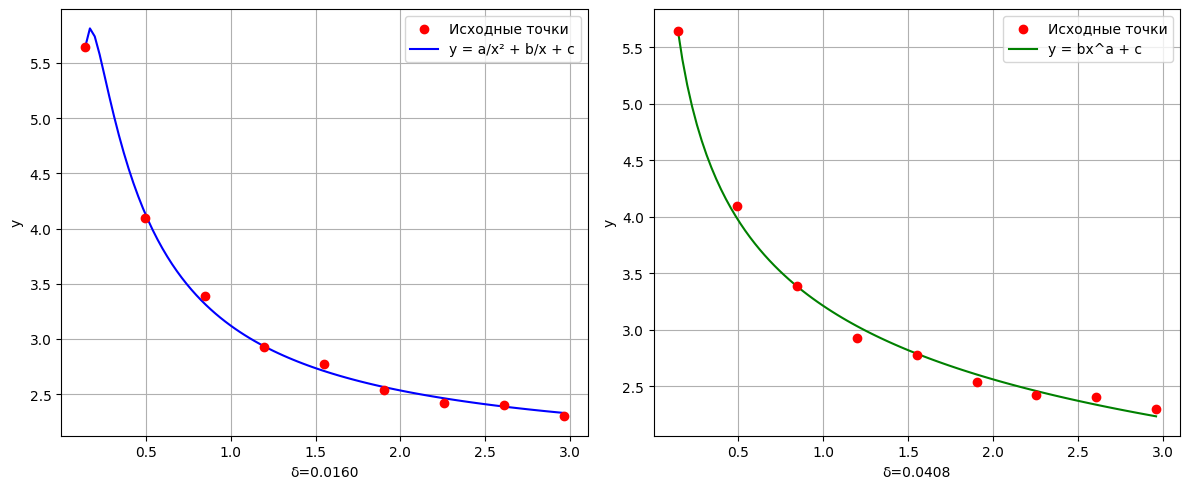

In [100]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x, y, color='red', label='Исходные точки', zorder=5)
x_plot = np.linspace(min(x), max(x), 100)
y_plot = best1['law'](x_plot, best1['a'], best1['b'], best1['c'])
plt.plot(x_plot, y_plot, 'b-', label=f"{best1['name']}")
plt.xlabel(f"δ={best1['delta']:.4f}")
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x, y, color='red', label='Исходные точки', zorder=5)
y_plot2 = best2['law'](x_plot, best2['a'], best2['b'], best2['c'])
plt.plot(x_plot, y_plot2, 'g-', label=f"{best2['name']}")
plt.xlabel(f"δ={best2['delta']:.4f}")
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()